<a href="https://colab.research.google.com/github/Harsh-bot-1603/AlexNet_Implementation/blob/main/AlexNet_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
class AlexNet(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.feature_extractor = nn.Sequential(
        nn.Conv2d(in_channels=3,
                  out_channels=96,
                  kernel_size=(11,11),
                  stride=4,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(3,3),
                     stride=2),
        nn.Conv2d(in_channels=96,
                  out_channels=256,
                  kernel_size=(5,5),
                  stride=1,
                  padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(3,3),stride=2),
        nn.Conv2d(in_channels=256,
                  out_channels=384,
                  kernel_size=(3,3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=384,
                  out_channels=384,
                  kernel_size=(3,3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=384,
                  out_channels=256,
                  kernel_size=(3,3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(3,3),
                     stride=2)
        )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=9216,
                  out_features=4096),
        nn.ReLU(),
        nn.Dropout(),
        nn.Linear(in_features=4096,
                  out_features=4096),
        nn.ReLU(),
        nn.Dropout(),
        nn.Linear(in_features=4096,
                  out_features=10)
    )
  def forward(self,x):
    x= self.feature_extractor(x)
    x = self.classifier(x)
    return x

In [4]:
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(size=(227,227)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(227,227)),
    transforms.ToTensor()
])

In [24]:
train_data = datasets.CIFAR10(root="train_dir",
                              train=True,
                              download=True,
                              transform=train_transform,
                              target_transform=None)
test_data = datasets.CIFAR10(root="test_dir",
                             train=False,
                             download=True,
                             transform=test_transform,
                             target_transform=None)

In [25]:
len(train_data),len(test_data)

(50000, 10000)

In [26]:
image,label = train_data[0]
print(image," ",label)

tensor([[[0.2275, 0.2275, 0.2275,  ..., 0.5804, 0.5804, 0.5804],
         [0.2275, 0.2275, 0.2275,  ..., 0.5804, 0.5804, 0.5804],
         [0.2275, 0.2275, 0.2275,  ..., 0.5804, 0.5804, 0.5804],
         ...,
         [0.6902, 0.6902, 0.6902,  ..., 0.4784, 0.4784, 0.4784],
         [0.6902, 0.6902, 0.6902,  ..., 0.4784, 0.4784, 0.4784],
         [0.6902, 0.6902, 0.6902,  ..., 0.4784, 0.4784, 0.4784]],

        [[0.2431, 0.2431, 0.2431,  ..., 0.4863, 0.4863, 0.4863],
         [0.2431, 0.2431, 0.2431,  ..., 0.4863, 0.4863, 0.4863],
         [0.2431, 0.2431, 0.2431,  ..., 0.4863, 0.4863, 0.4863],
         ...,
         [0.5647, 0.5647, 0.5647,  ..., 0.3608, 0.3608, 0.3608],
         [0.5647, 0.5647, 0.5647,  ..., 0.3608, 0.3608, 0.3608],
         [0.5647, 0.5647, 0.5647,  ..., 0.3608, 0.3608, 0.3608]],

        [[0.2431, 0.2431, 0.2431,  ..., 0.4000, 0.4000, 0.4000],
         [0.2431, 0.2431, 0.2431,  ..., 0.4000, 0.4000, 0.4000],
         [0.2431, 0.2431, 0.2431,  ..., 0.4000, 0.4000, 0.

In [9]:
image.shape

torch.Size([3, 227, 227])

In [27]:
from torch.utils.data import DataLoader
torch.manual_seed(42)
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=64,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=64,
                             shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bdb496096d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7bdb4973f950>)

In [28]:
train_features_batch,train_lables_batch = next(iter(train_dataloader))
train_features_batch,train_lables_batch = train_features_batch.to(device),train_lables_batch.to(device)
train_features_batch.shape,train_lables_batch.shape

(torch.Size([64, 3, 227, 227]), torch.Size([64]))

In [29]:
model = AlexNet().to(device)
model

AlexNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(3, 3), stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(3, 3), stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=(3, 3), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=4096, out_features

In [30]:
torch.manual_seed(42)
with torch.inference_mode():
  y_logits = model(train_features_batch)


In [31]:
y_logits.shape

torch.Size([64, 10])

In [32]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=0.00001)

In [33]:
from tqdm import tqdm
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 10
train_loss_values = []
train_acc_values = []
test_loss_values = []
test_acc_values = []
epoch_count = []
for epoch in tqdm(range(EPOCHS)):
  model.train()
  train_loss,train_acc=0,0
  for Batch,(X_train,y_train) in enumerate(train_dataloader):
    X_train,y_train = X_train.to(device) , y_train.to(device)
    y_logits = model(X_train)
    loss = loss_fn(y_logits,y_train)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Add gradient clipping
    optimizer.step()
    train_loss += loss.item()
    y_pred_probs = torch.softmax(y_logits,dim=1)
    y_preds = torch.argmax(y_pred_probs,dim=1)
    acc = torch.eq(y_preds,y_train).sum().item()/len(y_preds)
    train_acc += acc
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  test_loss,test_acc = 0,0
  model.eval()
  with torch.inference_mode():
    for Batch,(X_test,y_test) in enumerate(test_dataloader):
      X_test,y_test = X_test.to(device),y_test.to(device)
      test_logits = model(X_test)
      loss = loss_fn(test_logits,y_test)
      test_loss += loss.item()
      test_pred_probs = torch.softmax(test_logits,dim=1)
      test_preds = torch.argmax(test_pred_probs,dim=1)
      acc = torch.eq(test_preds,y_test).sum().item()/len(test_preds)
      test_acc += acc

  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

  train_loss_values.append(train_loss)
  train_acc_values.append(train_acc)
  test_loss_values.append(test_loss)
  test_acc_values.append(test_acc)
  epoch_count.append(epoch)

  print(f"Epoch {epoch+1}/{EPOCHS} : Train Loss : {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f} ")

 10%|█         | 1/10 [03:25<30:52, 205.85s/it]

Epoch 1/10 : Train Loss : 2.0909 | Train Accuracy: 0.2161 | Test Loss : 1.8135 | Test Accuracy : 0.3280 


 20%|██        | 2/10 [06:52<27:31, 206.47s/it]

Epoch 2/10 : Train Loss : 1.8868 | Train Accuracy: 0.3062 | Test Loss : 1.6073 | Test Accuracy : 0.4070 


 30%|███       | 3/10 [10:23<24:18, 208.29s/it]

...

Epoch 8/10 : Train Loss : 1.5547 | Train Accuracy: 0.4433 | Test Loss : 1.3068 | Test Accuracy : 0.5286 


 90%|█████████ | 9/10 [31:25<03:30, 210.23s/it]

Epoch 9/10 : Train Loss : 1.5054 | Train Accuracy: 0.4611 | Test Loss : 1.2994 | Test Accuracy : 0.5308 


100%|██████████| 10/10 [34:57<00:00, 209.74s/it]

Epoch 10/10 : Train Loss : 1.4782 | Train Accuracy: 0.4717 | Test Loss : 1.2340 | Test Accuracy : 0.5579 


In [34]:
X_test,y_test = next(iter(test_dataloader))
X_test,y_test = X_test.to(device),y_test.to(device)
model.eval()
loss,acc = 0,0
with torch.inference_mode():
  y_logits = model(X_test)
  y_pred_probs = torch.softmax(y_logits,dim=1)
  y_preds = torch.argmax(y_pred_probs,dim=1)
  loss = loss_fn(y_logits,y_test)/len(y_preds)
  acc = torch.eq(y_test,y_preds).sum().item()/len(y_preds)
print(f"Loss : {loss} | Accuracy : {acc}")

Loss : 0.01898840442299843 | Accuracy : 0.5625


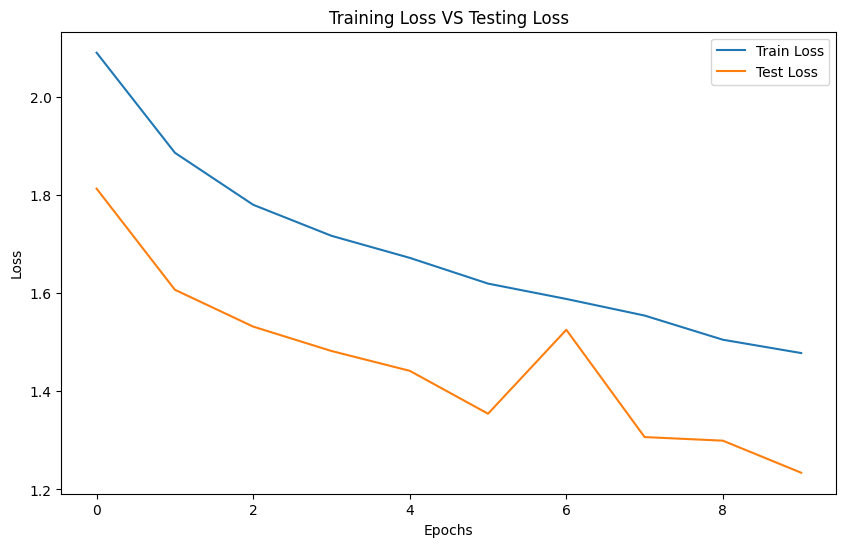

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training Loss VS Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

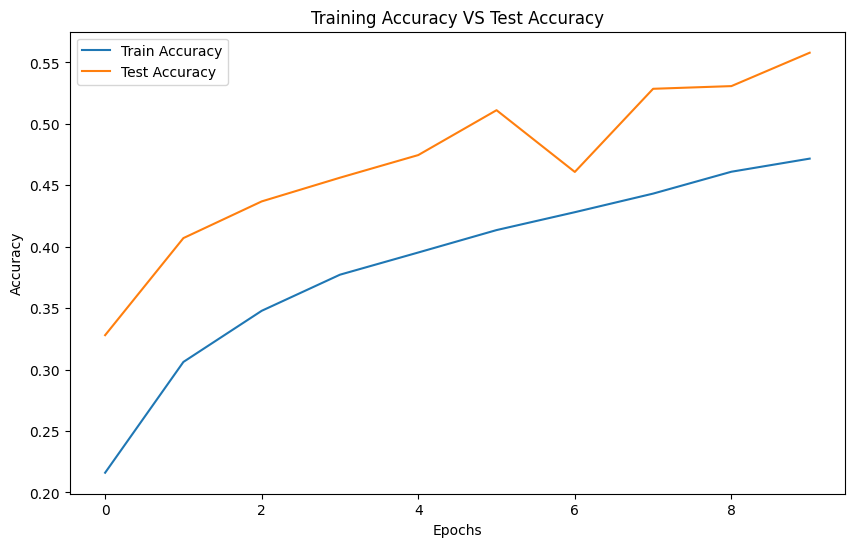

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(epoch_count, train_acc_values, label="Train Accuracy")
plt.plot(epoch_count, test_acc_values, label="Test Accuracy")
plt.title("Training Accuracy VS Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()